In [13]:
# 1. Tool Creation & Schema Imports
from langchain_core.tools import tool, BaseTool, StructuredTool
from pydantic import BaseModel, Field

# 2. Messages & State Management
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from typing import TypedDict, Annotated
import operator

# 3. LangGraph Workflow & Prebuilt Tool Execution
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# 4. Advanced Tool Context Injection (Optional)
from langgraph.prebuilt import InjectedState, InjectedStore



In [14]:
!pip install langchain-huggingface
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

In [5]:
import requests
import random

In [16]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    max_new_tokens=512,
    huggingfacehub_api_token=HF_API_KEY,
)

model = ChatHuggingFace(llm=llm)
result = model.invoke("what is the capital of india")
print(result.content)

The capital of India is New Delhi.


In [4]:
!pip install langchain-community
from langchain_community.tools import DuckDuckGoSearchRun

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

In [8]:
!pip install -U ddgs
search_tool = DuckDuckGoSearchRun()
search_tool.invoke("what is the capital of india")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 884.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 26.0 MB/s eta 0:00:00


"1 week ago - New Delhi is a city and the capital city of India and a part of the National Capital Territory of Delhi (NCT). New Delhi is the seat of all three branches of the Government of India, hosting the Rashtrapati Bhavan (Presidential Palace), Sansad Bhavan (Parliament House), and the Supreme Court. March 10, 2026 - This is a list of locations which have served as capital cities in India. The current capital city is New Delhi, which replaced Calcutta in 1911. 1 week ago - Delhi ranks fifth among the Indian ... GDP per capita in India (after Goa). Although a union territory, the political administration of the NCT of Delhi today more closely resembles that of a state of India, with its own legislature, high court and an executive council of ministers headed by a chief minister. New Delhi is jointly ... December 2, 2025 - New Delhi serves as the capital of India and stands as one of the most important political centers in the world. This bustling metropolis is home to the Indian P

In [10]:
from langchain_core.tools import tool

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """A simple calculator that can add, subtract, multiply, or divide two numbers.

    Args:
        first_num: The first number.
        second_num: The second number.
        operation: The operation to perform ('add', 'subtract', 'multiply', 'divide').
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "subtract":
            result = first_num - second_num
        elif operation == "multiply":
            result = first_num * second_num
        elif operation == "divide":
            if second_num == 0:
                return {"error": "Division by zero is not allowed."}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'. Use add, subtract, multiply, or divide."}

        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}

In [17]:
tools = [search_tool,calculator]
llm_with_tools  = model.bind_tools(tools=tools)

In [20]:
from langchain_core.messages import HumanMessage, AIMessage,BaseMessage

In [18]:
import operator
from typing import TypedDict, Annotated

class GraphState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]

In [25]:
def chat_node(state:GraphState):
  """LLM node that answer or request a tool call."""
  message = state['messages']
  response = llm_with_tools.invoke(message)
  return {"messages": [response]}

tool_node = ToolNode(tools)

In [44]:
graph = StateGraph(GraphState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)



In [45]:
graph.add_edge(START,'chat_node')

#if the llm asked for a tool, got to TOOLNODE
graph.add_conditional_edges("chat_node",tools_condition)

graph.add_edge('tools','chat_node')

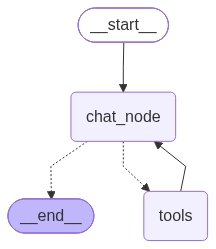

In [46]:
chat_bot = graph.compile()
chat_bot

In [48]:
out = chat_bot.invoke({"messages":[HumanMessage(content="what is the capital of india")]})
print(out['messages'][0].content)

content='what is the capital of india' additional_kwargs={} response_metadata={}


In [49]:
print(out['messages'][0].content)

what is the capital of india


In [50]:
print(out['messages'][-1].content)

The capital of India is New Delhi.
